# Exploratory Data Analysis
Capstone Project — Emerging Job Trends in New Brunswick

This notebook explores employment trends by occupation group
in New Brunswick using Statistics Canada labour force data.

## 2 - Imports

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

## 3 - Paths

In [106]:
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
FIGURES = PROJECT_ROOT / "figures"

FIGURES.mkdir(exist_ok=True)

## 4 - Load Dataset

In [107]:
df = pd.read_parquet(DATA_INTERIM / "nb_employment_by_occupation.parquet")

print(df.shape)
df.head()

(1534, 8)


,REF_DATE,GEO,Labour force characteristics,National Occupational Classification (NOC),Gender,VALUE,NOC_CODE,sector_group
0,2000,New Brunswick,Employment,"Total, all occupations [00-95]",Total - Gender,331.6,00-95,Other
1,2000,New Brunswick,Employment,"Management occupations [00, 10, 20, 30, 40, 50...",Total - Gender,29.6,"00, 10, 20, 30, 40, 50, 60, 70, 80, 90",Other
2,2000,New Brunswick,Employment,Legislative and senior management occupations [0],Total - Gender,1.0,0,Other
3,2000,New Brunswick,Employment,"Specialized middle management occupations [10,...",Total - Gender,8.0,"10, 20, 30, 40, 50",Other
4,2000,New Brunswick,Employment,Middle management occupations in retail and wh...,Total - Gender,13.6,60,Other


## 5 - Basic Dataset Info

In [108]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1534 entries, 0 to 1533
Data columns (total 8 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   REF_DATE                                    1534 non-null   int64  
 1   GEO                                         1534 non-null   str    
 2   Labour force characteristics                1534 non-null   str    
 3   National Occupational Classification (NOC)  1534 non-null   str    
 4   Gender                                      1534 non-null   str    
 5   VALUE                                       1532 non-null   float64
 6   NOC_CODE                                    1534 non-null   str    
 7   sector_group                                1534 non-null   str    
dtypes: float64(1), int64(1), str(6)
memory usage: 268.6 KB


,REF_DATE,VALUE
count,1534.000000,1532.000000
mean,2012.500000,19.394974
std,7.502446,47.558081
min,2000.000000,0.500000
25%,2006.000000,3.900000
50%,2012.500000,8.500000
75%,2019.000000,15.900000
max,2025.000000,405.200000


## Employment evolution in New Brunswick

In [109]:
employment_by_year = (
    df.groupby("REF_DATE")["VALUE"]
    .sum()
    .reset_index()
)

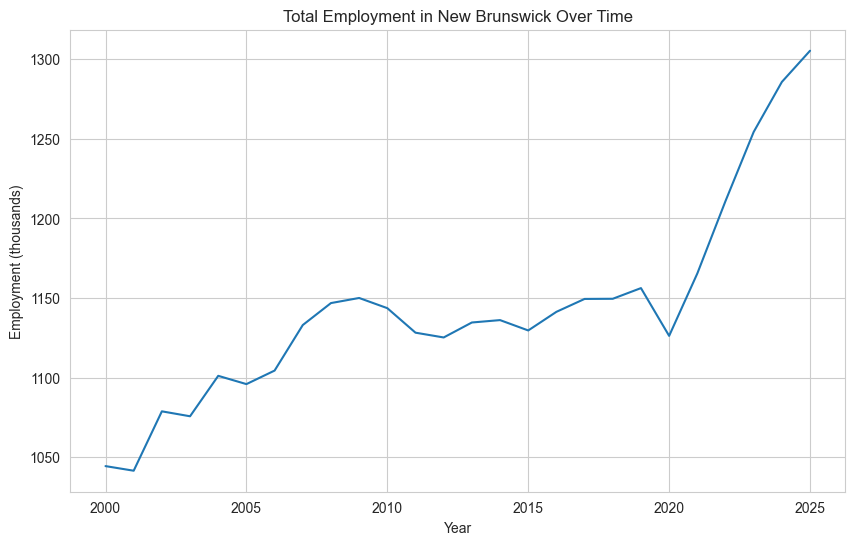

In [110]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=employment_by_year,
    x="REF_DATE",
    y="VALUE"
)

plt.title("Total Employment in New Brunswick Over Time")
plt.xlabel("Year")
plt.ylabel("Employment (thousands)")
plt.show()

## Employment by sector group

In [111]:
sector_trends = (
    df.groupby(["REF_DATE","sector_group"])["VALUE"]
    .sum()
    .reset_index()
)

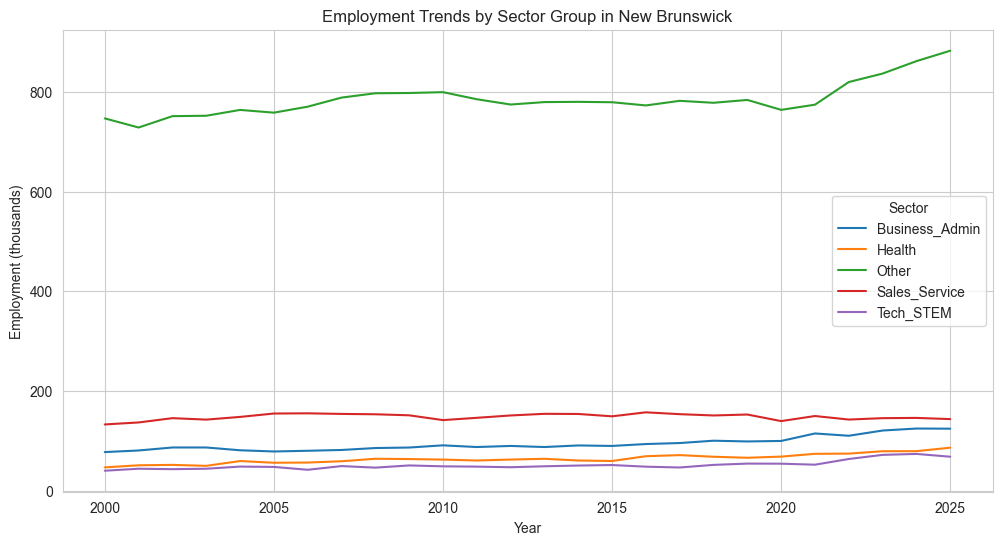

In [112]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=sector_trends,
    x="REF_DATE",
    y="VALUE",
    hue="sector_group"
)

plt.title("Employment Trends by Sector Group in New Brunswick")
plt.xlabel("Year")
plt.ylabel("Employment (thousands)")
plt.legend(title="Sector")
plt.show()

## Tech employment growth

In [113]:
tech_trend = (
    df[df["sector_group"] == "Tech_STEM"]
    .groupby("REF_DATE")["VALUE"]
    .sum()
    .reset_index()
)

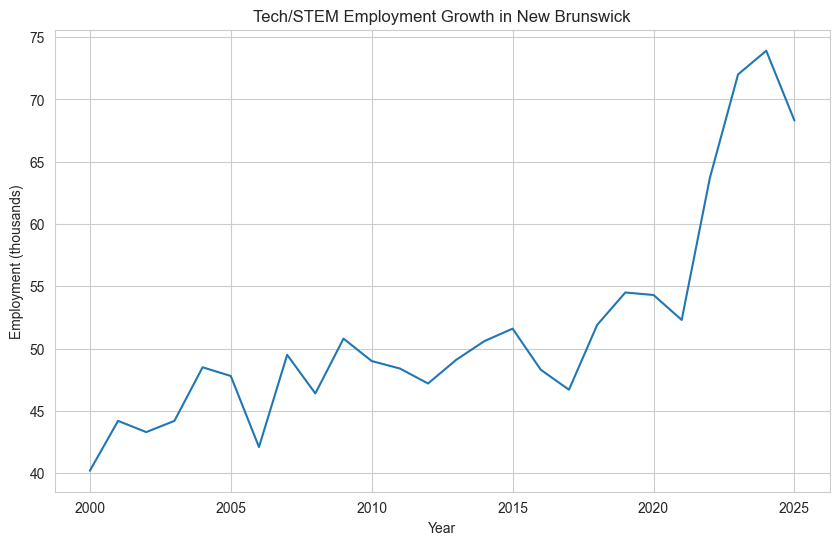

In [114]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=tech_trend,
    x="REF_DATE",
    y="VALUE"
)

plt.title("Tech/STEM Employment Growth in New Brunswick")
plt.xlabel("Year")
plt.ylabel("Employment (thousands)")
plt.show()

## Fastest Growing Occupations in New Brunswick
This section identifies which occupations have experienced the highest employment growth in the last decade.

In [115]:
growth_df = (
    df.groupby(["REF_DATE","National Occupational Classification (NOC)"])["VALUE"]
    .sum()
    .reset_index()
)

growth_df.head()

,REF_DATE,National Occupational Classification (NOC),VALUE
0,2000,Administrative and financial supervisors and s...,8.2
1,2000,Administrative and financial support and suppl...,20.3
2,2000,Administrative occupations and transportation ...,11.3
3,2000,Assisting occupations in education and in lega...,3.5
4,2000,Assisting occupations in support of health ser...,4.8


In [116]:
# Pivot the data to have NOC codes as rows and years as columns
pivot_growth = growth_df.pivot(
    index="National Occupational Classification (NOC)",
    columns="REF_DATE",
    values="VALUE"
)

pivot_growth.head()

REF_DATE,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
National Occupational Classification (NOC),,,,,,,,,,,,,,,,,,,,,
Administrative and financial supervisors and specialized administrative occupations [12],8.2,9.6,9.4,10.3,7.4,7.7,7.6,7.8,8.7,8.4,...,10.2,9.9,10.5,11.2,10.7,15.0,12.7,13.2,15.5,15.8
Administrative and financial support and supply chain logistics occupations [14],20.3,18.8,20.2,21.4,22.1,22.3,19.3,21.2,21.9,22.0,...,16.4,15.7,17.5,15.4,14.9,16.4,13.9,14.2,17.5,17.1
Administrative occupations and transportation logistics occupations [13],11.3,10.6,12.5,11.8,11.2,10.8,10.5,11.1,10.3,10.0,...,12.8,15.1,13.1,13.5,15.4,15.1,15.4,16.4,16.8,17.5
Assisting occupations in education and in legal and public protection [43],3.5,3.5,2.5,3.4,3.3,3.4,4.1,4.1,3.6,3.9,...,4.1,4.6,4.8,5.2,6.0,6.7,6.0,6.2,6.7,6.6
Assisting occupations in support of health services [33],4.8,5.5,5.4,5.7,5.8,6.0,6.4,5.7,9.0,7.8,...,8.4,9.5,10.6,9.4,9.2,10.2,10.2,12.1,11.5,11.7


In [117]:
# Calculate job growth over the last 10 years.
start_year = pivot_growth.columns.max() - 10
end_year = pivot_growth.columns.max()

growth_rates = (
    (pivot_growth[end_year] - pivot_growth[start_year]) 
    / pivot_growth[start_year]
) * 100

growth_rates = growth_rates.reset_index()
growth_rates.columns = ["occupation", "growth_percent"]

growth_rates.head()

,occupation,growth_percent
0,Administrative and financial supervisors and s...,61.224490
1,Administrative and financial support and suppl...,-14.925373
2,Administrative occupations and transportation ...,98.863636
3,Assisting occupations in education and in lega...,29.411765
4,Assisting occupations in support of health ser...,25.806452


In [118]:
# Identify the occupations that have grown the most.
top_growth = growth_rates.sort_values(
    "growth_percent",
    ascending=False
).head(15)

top_growth

,occupation,growth_percent
36,Professional occupations in government service...,119.230769
2,Administrative occupations and transportation ...,98.863636
38,Professional occupations in law [411],85.714286
55,Therapy and assessment professionals [312],76.923077
29,Professional occupations in applied sciences (...,76.470588
31,Professional occupations in business [112],66.666667
47,"Specialized middle management occupations [10,...",64.634146
0,Administrative and financial supervisors and s...,61.224490
10,Health treating and consultation services prof...,59.459459
40,Professional occupations in natural and applie...,55.434783


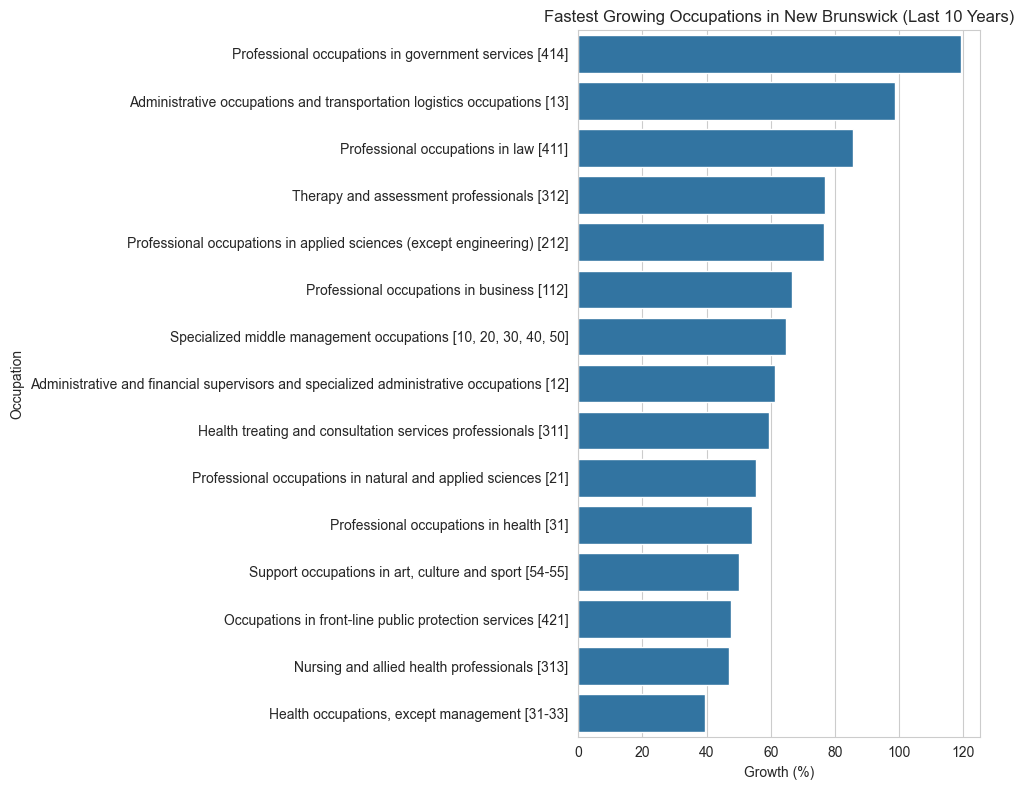

In [119]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=top_growth,
    y="occupation",
    x="growth_percent"
)

plt.title("Fastest Growing Occupations in New Brunswick (Last 10 Years)")
plt.xlabel("Growth (%)")
plt.ylabel("Occupation")

plt.tight_layout()

plt.savefig(FIGURES / "fastest_growing_occupations_nb.png", dpi=300)

plt.show()

In [120]:
# Preparing the Canada dataset for comparison.
cols = [
    "REF_DATE",
    "GEO",
    "Labour force characteristics",
    "National Occupational Classification (NOC)",
    "Gender",
    "VALUE"
]

df_full = pd.read_csv(
    DATA_RAW / "statcan_14-10-0416-01_full.csv",
    usecols=cols
)

df_can = df_full[
    (df_full["GEO"] == "Canada") &
    (df_full["Labour force characteristics"] == "Employment") &
    (df_full["Gender"] == "Total - Gender")
]

df_can.head()

,REF_DATE,GEO,Labour force characteristics,National Occupational Classification (NOC),Gender,VALUE
180,1987,Canada,Employment,"Total, all occupations [00-95]",Total - Gender,12333.0
183,1987,Canada,Employment,"Management occupations [00, 10, 20, 30, 40, 50...",Total - Gender,1333.7
186,1987,Canada,Employment,Legislative and senior management occupations [0],Total - Gender,69.9
189,1987,Canada,Employment,"Specialized middle management occupations [10,...",Total - Gender,307.4
192,1987,Canada,Employment,Middle management occupations in retail and wh...,Total - Gender,493.6


In [121]:
latest_year = df["REF_DATE"].max()
latest_year

np.int64(2025)

### Employment by sector in New Brunswick in 2025

In [122]:
nb_sector = (
    df[df["REF_DATE"] == latest_year]
    .groupby("sector_group")["VALUE"]
    .sum()
)

nb_sector

sector_group
Business_Admin    124.5
Health             86.4
Other             882.4
Sales_Service     143.7
Tech_STEM          68.3
Name: VALUE, dtype: float64

In [123]:
# Employment by occupation in Canada in 2025
can_latest = df_can[df_can["REF_DATE"] == latest_year]
can_latest.head()

,REF_DATE,GEO,Labour force characteristics,National Occupational Classification (NOC),Gender,VALUE
520590,2025,Canada,Employment,"Total, all occupations [00-95]",Total - Gender,21028.7
520593,2025,Canada,Employment,"Management occupations [00, 10, 20, 30, 40, 50...",Total - Gender,2043.9
520596,2025,Canada,Employment,Legislative and senior management occupations [0],Total - Gender,35.1
520599,2025,Canada,Employment,"Specialized middle management occupations [10,...",Total - Gender,871.1
520602,2025,Canada,Employment,Middle management occupations in retail and wh...,Total - Gender,541.7


In [124]:
# Total employment in Canada in 2025
can_sector = (
    can_latest.groupby("National Occupational Classification (NOC)")["VALUE"]
    .sum()
)
can_sector.head()

National Occupational Classification (NOC)
Administrative and financial supervisors and specialized administrative occupations [12]    689.9
Administrative and financial support and supply chain logistics occupations [14]            819.7
Administrative occupations and transportation logistics occupations [13]                    775.6
Assisting occupations in education and in legal and public protection [43]                  215.1
Assisting occupations in support of health services [33]                                    477.2
Name: VALUE, dtype: float64

In [125]:
# Total employment in Canada in 2025
can_total = can_latest["VALUE"].sum()

can_total

np.float64(68440.20000000001)

In [126]:
# Total employment in New Brunswick in 2025
nb_total = nb_sector.sum()

nb_total

np.float64(1305.3)

In [127]:
# Each sector's share in New Brunswick
nb_share = nb_sector / nb_total

nb_share

sector_group
Business_Admin    0.095380
Health            0.066192
Other             0.676013
Sales_Service     0.110090
Tech_STEM         0.052325
Name: VALUE, dtype: float64

In [128]:
# Each sector's share in Canada
can_share = can_sector / can_total

can_share.head()

National Occupational Classification (NOC)
Administrative and financial supervisors and specialized administrative occupations [12]    0.010080
Administrative and financial support and supply chain logistics occupations [14]            0.011977
Administrative occupations and transportation logistics occupations [13]                    0.011333
Assisting occupations in education and in legal and public protection [43]                  0.003143
Assisting occupations in support of health services [33]                                    0.006973
Name: VALUE, dtype: float64

In [129]:
# Adjusting for specialization using Location Quotient
def classify_sector(noc):
    if pd.isna(noc):
        return "Other"
    noc = str(noc)
    if noc.startswith("21") or noc.startswith("22"):
        return "Tech_STEM"
    elif noc.startswith("11") or noc.startswith("12") or noc.startswith("13"):
        return "Business_Admin"
    elif noc.startswith("31") or noc.startswith("32"):
        return "Health"
    elif noc.startswith("62") or noc.startswith("63") or noc.startswith("64"):
        return "Sales_Service"
    else:
        return "Other"

In [130]:
df_can["NOC_CODE"] = df_can["National Occupational Classification (NOC)"].str.extract(r"\[(.*?)\]")
df_can["sector_group"] = df_can["NOC_CODE"].apply(classify_sector)
df_can.head()

,REF_DATE,GEO,Labour force characteristics,National Occupational Classification (NOC),Gender,VALUE,NOC_CODE,sector_group
180,1987,Canada,Employment,"Total, all occupations [00-95]",Total - Gender,12333.0,00-95,Other
183,1987,Canada,Employment,"Management occupations [00, 10, 20, 30, 40, 50...",Total - Gender,1333.7,"00, 10, 20, 30, 40, 50, 60, 70, 80, 90",Other
186,1987,Canada,Employment,Legislative and senior management occupations [0],Total - Gender,69.9,0,Other
189,1987,Canada,Employment,"Specialized middle management occupations [10,...",Total - Gender,307.4,"10, 20, 30, 40, 50",Other
192,1987,Canada,Employment,Middle management occupations in retail and wh...,Total - Gender,493.6,60,Other


In [131]:
can_sector_grouped = (
    df_can[df_can["REF_DATE"] == latest_year]
    .groupby("sector_group")["VALUE"]
    .sum()
)

can_sector_grouped

sector_group
Business_Admin     6997.9
Health             3777.5
Other             45268.6
Sales_Service      7244.1
Tech_STEM          5152.1
Name: VALUE, dtype: float64

In [132]:
# Calculate participation share for each sector in Canada
can_share_grouped = can_sector_grouped / can_total

can_share_grouped

sector_group
Business_Admin    0.102248
Health            0.055194
Other             0.661433
Sales_Service     0.105846
Tech_STEM         0.075279
Name: VALUE, dtype: float64

In [134]:
# Calculate Location Quotient
lq = nb_share / can_share_grouped
lq.head()

sector_group
Business_Admin    0.932830
Health            1.199251
Other             1.022043
Sales_Service     1.040096
Tech_STEM         0.695084
Name: VALUE, dtype: float64

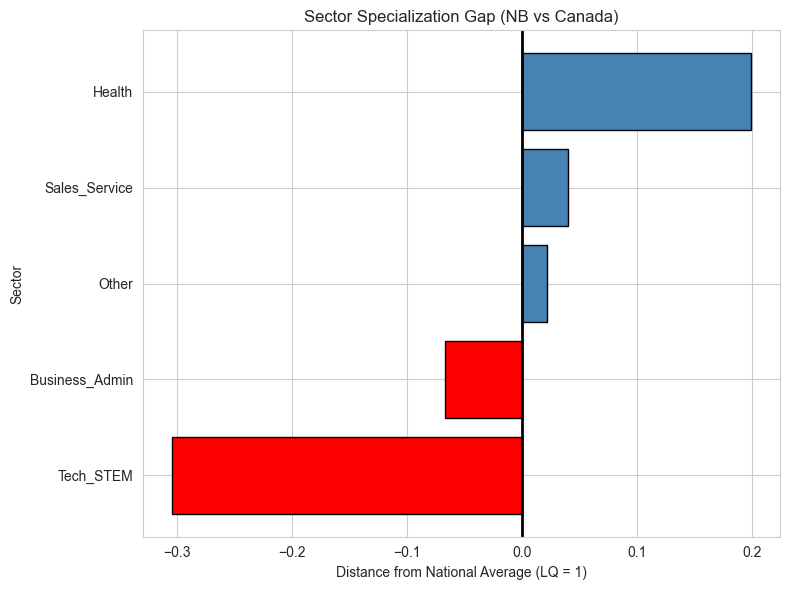

In [137]:
import numpy as np

lq_sorted = lq.sort_values()

gap = lq_sorted - 1

colors = [
    "steelblue" if val >= 0 else "red"
    for val in gap
]

plt.figure(figsize=(8,6))

plt.barh(
    lq_sorted.index,
    gap,
    color=colors,
    edgecolor="black"
)

plt.axvline(
    x=0,
    color="black",
    linewidth=2
)

plt.title("Sector Specialization Gap (NB vs Canada)")
plt.xlabel("Distance from National Average (LQ = 1)")
plt.ylabel("Sector")

plt.tight_layout()

plt.savefig(FIGURES / "location_quotient_gap_nb.png", dpi=300)

plt.show()